<a href="https://colab.research.google.com/github/Vaishnavi200527/RollNo_39_MLDL_Lab/blob/main/mldllab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
data = pd.read_csv("/content/dermatology_database_1.csv")

print("Dataset Shape:", data.shape)
print(data.head())

Dataset Shape: (366, 35)
   erythema  scaling  definite_borders  itching  koebner_phenomenon  \
0         2        2                 0        3                   0   
1         3        3                 3        2                   1   
2         2        1                 2        3                   1   
3         2        2                 2        0                   0   
4         2        3                 2        2                   2   

   polygonal_papules  follicular_papules  oral_mucosal_involvement  \
0                  0                   0                         0   
1                  0                   0                         0   
2                  3                   0                         3   
3                  0                   0                         0   
4                  2                   0                         2   

   knee_and_elbow_involvement  scalp_involvement  ...  \
0                           1                  0  ...   
1            

In [4]:
data.replace('?', np.nan, inplace=True)
data = data.apply(pd.to_numeric)
data.fillna(data.mean(), inplace=True)

In [5]:
X = data.drop("class", axis=1)
y = data["class"]


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [7]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("\n========== Decision Tree Results ==========")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))



========== Decision Tree Results ==========
Accuracy: 0.9818181818181818

Confusion Matrix:
 [[40  0  0  0  0  0]
 [ 0 15  0  1  0  0]
 [ 0  0 19  0  0  0]
 [ 0  1  0 14  0  0]
 [ 0  0  0  0 16  0]
 [ 0  0  0  0  0  4]]

Classification Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00        40
           2       0.94      0.94      0.94        16
           3       1.00      1.00      1.00        19
           4       0.93      0.93      0.93        15
           5       1.00      1.00      1.00        16
           6       1.00      1.00      1.00         4

    accuracy                           0.98       110
   macro avg       0.98      0.98      0.98       110
weighted avg       0.98      0.98      0.98       110



In [10]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("\n========== Random Forest Results ==========")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))


========== Random Forest Results ==========
Accuracy: 0.9636363636363636

Confusion Matrix:
 [[40  0  0  0  0  0]
 [ 0 15  0  1  0  0]
 [ 0  0 19  0  0  0]
 [ 0  3  0 12  0  0]
 [ 0  0  0  0 16  0]
 [ 0  0  0  0  0  4]]

Classification Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00        40
           2       0.83      0.94      0.88        16
           3       1.00      1.00      1.00        19
           4       0.92      0.80      0.86        15
           5       1.00      1.00      1.00        16
           6       1.00      1.00      1.00         4

    accuracy                           0.96       110
   macro avg       0.96      0.96      0.96       110
weighted avg       0.97      0.96      0.96       110



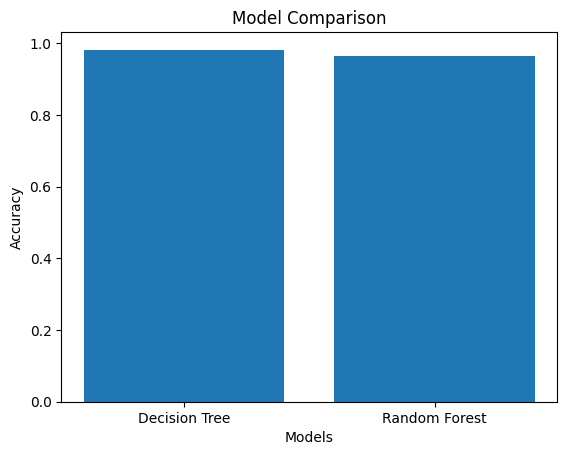

In [11]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

models = ['Decision Tree', 'Random Forest']
accuracies = [dt_accuracy, rf_accuracy]

plt.bar(models, accuracies)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()